**Fake News Prediction**

Dataset: WELFake_Dataset.csv

Kaggle Link: https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification

In [4]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn

**1. Setup**

In [5]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)


In [6]:
# Configurations

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

plt.rcParams.update({"figure.figsize": (10, 8),
                     "axes.titlesize": 20,
                     "axes.labelsize": 15,
                     "xtick.labelsize": 15,
                     "ytick.labelsize":15})

CSV_PATH = "https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification"
RANDOM_STATE = 42
TARGET_COL = "label"

**2. Load Data and Sample**

In [7]:
df = pd.read_csv('/content/sample_data/WELFake_Dataset.csv', on_bad_lines='skip', engine='python')

In [8]:
df.shape

(72154, 4)

In [9]:
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [10]:
df = df.drop(columns=["Unnamed: 0"])

In [11]:
df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


**Get a Sample for faster processing and training.**

In [12]:
print(df["label"].value_counts())
print("-"*50)
print(df["label"].value_counts(normalize=True)*100)

label
1                                                  37104
0                                                  35028
 is just unbelievably rich from North Sea oil.         1
 за участие. Благодарю вас.                            1
Name: count, dtype: int64
--------------------------------------------------
label
1                                                 51.438
0                                                 48.560
 is just unbelievably rich from North Sea oil.     0.001
 за участие. Благодарю вас.                        0.001
Name: proportion, dtype: float64


In [13]:
n_samples = 10000

# Clean the 'label' column to ensure it contains only 0s and 1s as integers
df['label'] = pd.to_numeric(df['label'], errors='coerce')
df.dropna(subset=['label'], inplace=True)
df['label'] = df['label'].astype(int)

# Fake Data
df_fake = df[df["label"]==0]

# Real Data
df_real = df[df["label"]==1]

# Samples
df_fake = df_fake.sample(n_samples, random_state=RANDOM_STATE)
df_real = df_real.sample(n_samples, random_state=RANDOM_STATE)

df_sample = pd.concat([df_fake, df_real]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
# dataframe columns
df.columns

Index(['title', 'text', 'label'], dtype='object')

In [14]:
print(df_sample["label"].value_counts())
print("-"*50)
print(df_sample["label"].value_counts(normalize=True)*100)

label
1    10000
0    10000
Name: count, dtype: int64
--------------------------------------------------
label
1   50.000
0   50.000
Name: proportion, dtype: float64


**3. Exploratory Data Analysis & Data Preprocessing**

In [15]:
# dataframe columns
df_sample.columns

Index(['title', 'text', 'label'], dtype='object')

In [16]:
# basic data overview

df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   19854 non-null  object
 1   text    19989 non-null  object
 2   label   20000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 468.9+ KB


In [17]:
df_sample.isnull().sum()

,0
title,146
text,11
label,0


In [18]:
# less no of rows have null values, so, drop them off.
df_sample = df_sample.dropna().reset_index(drop=True)

In [19]:
df_sample.isnull().sum()

,0
title,0
text,0
label,0


In [20]:
# target distribution
print(df_sample["label"].value_counts())
print("="*40)
print(df_sample["label"].value_counts(normalize=True)*100)

label
0    10000
1     9843
Name: count, dtype: int64
label
0   50.396
1   49.604
Name: proportion, dtype: float64


**Text Cleaning**

In [21]:
def clean_text(s: str) -> str:
    """
    Simple text cleaning:
    - lowercasing
    - remove URLs
    - remove HTML tags
    - keep letters/numbers and basic punctuation
    - normalize spaces
    """

    if pd.isna(s):
      return ""

    s = str(s).lower()
    s = re.sub(r"http\S+|www\S+", " ", s)
    s = re.sub(r"<.*?>", " ", s)
    s = re.sub(r"[^a-zA-Z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s)

    return s

In [22]:
# example
a = "ABCabc  123*"
b = "zyxABC 999"

c = a + " " + b
print(c)

d = clean_text(c)

print(d)

ABCabc  123* zyxABC 999
abcabc 123 zyxabc 999


In [23]:
df_sample["content"] = (df_sample["title"] + " " + df_sample["text"]).apply(clean_text)

In [24]:
df_sample["content"].head()

,content
0,5 things you can do to challenge trump s presi...
1,pennsylvania bans bias against transgender peo...
2,u s lawmakers aim to comply with iran nuclear ...
3,more than 60 killed in air strike on syrian ma...
4,trump just attacked the doj gets his a handed...


In [25]:
# adding additional columns for analysis
df_sample["title_len_chars"] = df_sample["title"].str.len()
df_sample["text_len_chars"] = df_sample["text"].str.len()
df_sample["content_len_word"] = df_sample["content"].str.split().apply(len)

In [26]:
num_cols = ["title_len_chars", "text_len_chars", "content_len_word"]

df_sample[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
title_len_chars,19843.000,76.948,24.834,3.000,62.000,73.000,88.000,289.000
text_len_chars,19843.000,3257.605,3443.819,1.000,1407.000,2437.000,4053.000,85948.000
content_len_word,19843.000,560.623,584.375,0.000,247.000,421.000,694.000,14691.000


**Data Visualization**

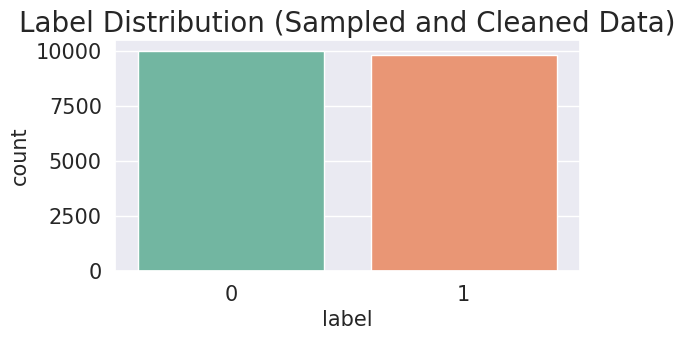

In [27]:
plt.figure(figsize=(6,3))
sns.countplot(x="label", data=df_sample, palette="Set2", hue="label", legend=False)
plt.title("Label Distribution (Sampled and Cleaned Data)")
plt.show()

**NOTE: Almost Equal class distribution**

/tmp/ipykernel_16688/1263800805.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_fake_lens, df_real_lens], labels=['Fake News', 'Real News'])


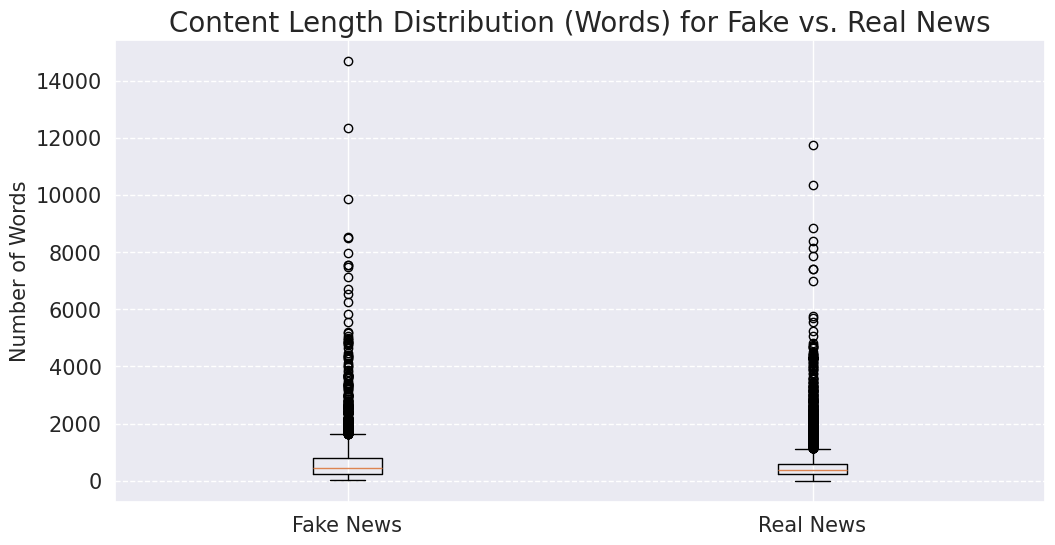

In [28]:
# text length distribution (words) - boxplot

df_fake_lens = df_sample[df_sample['label'] == 0]["content_len_word"].values
df_real_lens = df_sample[df_sample['label'] == 1]["content_len_word"].values

plt.figure(figsize=(12, 6))
plt.boxplot([df_fake_lens, df_real_lens], labels=['Fake News', 'Real News'])
plt.title('Content Length Distribution (Words) for Fake vs. Real News')
plt.ylabel('Number of Words')
plt.grid(axis='y', linestyle='--')
plt.show()

In [29]:
# Target Distribution

X = df_sample['content']
y = df_sample['label']

In [30]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

In [31]:
print("\nTrain size:", len(X_train), "| Test size:", len(X_test))


Train size: 15874 | Test size: 3969


**4. Vectorization & Model Training Pipeline**

TF-IDF rewards words that are frequent in a document but uncommon in the overall dataset. Words that appear everywhere are treated as less important.

In [32]:
model_pipeline = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(
            max_features=50000,
            ngram_range=(1,2),
            stop_words="english",
            min_df=2
        )),
        ("model", LogisticRegression())
    ]
)

**NOTE: No scaling required**

TF-IDF already produces normalized numerical features
Each feature represents a word importance score, not a raw magnitude.

In [33]:
# train the pipeline
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=50000, min_df=2,
                                 ngram_range=(1, 2), stop_words='english')),
                ('model', LogisticRegression())])

**5. Model Evaluation**

In [34]:
y_train_pred = model_pipeline.predict(X_train)
y_train_proba = model_pipeline.predict_proba(X_train)[:,1]

acc_train = accuracy_score(y_train, y_train_pred)
cm_train = confusion_matrix(y_train, y_train_pred)

print("\n--- Train Metrics ---")
print(f"Accuracy : {acc_train:.4f}")

print("\nConfusion Matrix [ [TN FP], [FN TP] ]:")
print(cm_train)

print("\nClassification Report:")
print(classification_report(y_train, y_train_pred, digits=4))



--- Train Metrics ---
Accuracy : 0.9604

Confusion Matrix [ [TN FP], [FN TP] ]:
[[7665  348]
 [ 280 7581]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9648    0.9566    0.9606      8013
           1     0.9561    0.9644    0.9602      7861

    accuracy                         0.9604     15874
   macro avg     0.9604    0.9605    0.9604     15874
weighted avg     0.9605    0.9604    0.9604     15874



In [35]:
y_test_pred = model_pipeline.predict(X_test)
y_test_proba = model_pipeline.predict_proba(X_test)[:,1]

acc_test = accuracy_score(y_test, y_test_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

print("\n--- Train Metrics ---")
print(f"Accuracy : {acc_test:.4f}")

print("\nConfusion Matrix [ [TN FP], [FN TP] ]:")
print(cm_test)

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, digits=4))



--- Train Metrics ---
Accuracy : 0.9385

Confusion Matrix [ [TN FP], [FN TP] ]:
[[1849  138]
 [ 106 1876]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9458    0.9305    0.9381      1987
           1     0.9315    0.9465    0.9389      1982

    accuracy                         0.9385      3969
   macro avg     0.9386    0.9385    0.9385      3969
weighted avg     0.9386    0.9385    0.9385      3969



**6. Build predictive system**

In [42]:
def predict_news(title, text):
    combined_text = clean_text(title + " " + text)
    prediction = model_pipeline.predict([combined_text])
    probability = model_pipeline.predict_proba([combined_text])[:,1]
    # print(prediction)
    # print(probability)
    if (prediction[0] == 1):
        print("This is a Real News 🟢",)
    else:
        print("This is a Fake News 🔴")

In [43]:
# Example prediction
example_title = "Breaking: Government announces new economic policy"
example_text = "The finance minister introduced a new policy today after discussions in parliament..."
prediction = predict_news(example_title, example_text)

This is a Real News 🟢
